# CeNTREX state cleanup — native Rust solver migration

Migrated from the legacy `centrex_tlf_julia_extension` workflow to `centrex-tlf 0.2.5` and its built-in Rust Lindblad solver. Select the **Python (CeNTREX_state_cleanup_new)** kernel. The full scans are expensive; reduce the scan axes while testing.


In [2]:
from importlib.metadata import version
import site
import sys

# Prefer the verified 0.2.5 wheel over this repository checkout when the notebook
# is opened from the source-tree root (which would otherwise shadow site-packages).
sys.path.insert(0, site.getsitepackages()[-1])

import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy import constants as cst

from centrex_tlf import couplings, hamiltonian, lindblad, states, transitions, utils

print("centrex-tlf", version("centrex-tlf"))


centrex-tlf 0.2.5


In [3]:
plt.rcParams['axes.titlesize']=24
plt.rcParams['axes.labelsize']=20
plt.rcParams['xtick.labelsize']=20
plt.rcParams['ytick.labelsize']=20
plt.rcParams['lines.linewidth']=3
plt.rcParams['legend.fontsize']=20

In [4]:
def doppler_shift(velocity, frequency):
    """calculate the doppler shifted frequency
    Args:
        velocity (float): velocity [m/s]
        frequency (float): frequency [Hz]
    Returns:
        float: doppler shifted frequency in Hz
    """
    return frequency * (1 + velocity / cst.c)


def velocity_to_detuning(velocity, frequency=1.103e15, Γ=2*np.pi*1.56e6):
    """convert velocity to detuning in units of Γ
    Args:
        velocity (float): velocity [m/s]
        frequency (float): frequency [Hz]
        Γ (float): Γ [2π⋅Hz]
    Returns:
        float: detuning in units of Γ
    """
    return (doppler_shift(velocity, frequency) - frequency) * 2 * np.pi / Γ

In [5]:
trans = [transitions.R1_F1_5o2_F2]

polarizations = [[couplings.polarization_X, couplings.polarization_Z]]

transition_selectors = couplings.generate_transition_selectors(
    trans,
    polarizations,
    ground_mains=[
        1 * states.CoupledBasisState(
            J=1, F=2, F1=3 / 2, mF=1, I1=1 / 2, I2=1 / 2,
            Ω=0, P=-1, electronic_state=states.ElectronicState.X,
        )
    ],
    excited_mains=[
        1 * states.CoupledBasisState(
            J=2, F=2, F1=5 / 2, mF=2, I1=1 / 2, I2=1 / 2,
            Ω=1, P=1, electronic_state=states.ElectronicState.B,
        )
    ],
)


In [6]:
def gen_multipass_para(npass, loss, fir_center, dz):
    pow_ord = []
    x_loc = []
    y_loc = []
    pow_para = 1 - loss
    multipas_ord = utils.multipass.multipass_prism_order(npass)
    for i, pass_time in enumerate(multipas_ord):
        x_loc.append(fir_center + i * dz)
        y_loc.append(0.)
        pow_ord.append(pow_para**(pass_time - 1))
    return x_loc, y_loc, pow_ord

xloctions, yloctions, pow = gen_multipass_para(13,0.10,3.5e-3,3.5e-3)
print(pow)

[1.0, 0.31381059609000006, 0.81, 0.3874204890000001, 0.6561, 0.4782969000000001, 0.531441, 0.5904900000000001, 0.4304672100000001, 0.7290000000000001, 0.3486784401000001, 0.9, 0.2824295364810001]


In [7]:
# Experimental/runtime settings. All frequencies are angular frequencies [rad/s].
laser_frequency = 1.103e15  # Hz
vz = 184.0                  # m/s
vx = 0.0                    # m/s
y0_default = 0.0
laser_detuning_default = 20.6 * 2 * np.pi * 1e6
phase_frequency_default = 0.0 * 2 * np.pi * 1e6
phase_depth_default = 1.5
polarization_frequency_default = 1.0 * 2 * np.pi * 1e6
polarization_phase_default = 0.0
power_default = 80e-3       # W

# The old notebook used sigma = diameter / 4 and peak intensity
# P / (2*pi*sigma_x*sigma_y) for each multipass beam.
dz = 0.75e-3 * 4
dy = 12e-3 * 4
sigma_z_default = dz / 4
sigma_y_default = dy / 4
intensities_per_watt = tuple(
    np.asarray(pow, dtype=float) / (2 * np.pi * sigma_z_default * sigma_y_default)
)


In [8]:
%%time
obe_system = lindblad.generate_OBE_system_transitions(
    trans,
    transition_selectors,
    verbose=True,
    qn_compact=True,
    decay_channels=None,
    E=np.array([0.0, 0.0, 150.0]),  # V/cm
    B=np.array([0.0, 0.0, 1e-3]),  # Gauss; resolves +/-mF robustly
    retain_opposite_parity_levels=True,
)


INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 1/5 -> Generating the reduced Hamiltonian
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 2/5 -> Generating the couplings corresponding to the transitions
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 3/5 -> Generating the symbolic Hamiltonian
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 4/5 -> Generating the collapse matrices
INFO:centrex_tlf.lindblad.utils_setup:generate_OBE_system: 5/5 -> Assembling the OBE system (symbolic system of equations is now built lazily on first access)


CPU times: total: 8.92 s
Wall time: 4.86 s


In [9]:
%%time
# Bind the old odeParameters expressions to the new native runtime-parameter graph.
params = lindblad.LindbladParameters()
t = params.time()
laser_power = params.real("laser_power", power_default)
laser_detuning = params.real("laser_detuning", laser_detuning_default)
phase_frequency = params.real("phase_frequency", phase_frequency_default)
phase_depth = params.real("phase_depth", phase_depth_default)
polarization_frequency = params.real(
    "polarization_frequency", polarization_frequency_default
)
polarization_phase = params.real("polarization_phase", polarization_phase_default)
y0 = params.real("y0", y0_default)
sigma_z = params.real("sigma_z", sigma_z_default)
sigma_y = params.real("sigma_y", sigma_y_default)
intensity_profile = params.real("intensities_per_watt", intensities_per_watt)
xlocs = params.real("xlocs", tuple(xloctions))
ylocs = params.real("ylocs", tuple(yloctions))
main_coupling = params.real(
    "main_coupling", float(abs(obe_system.couplings[0].main_coupling))
)

# multipass_2d_rabi scales as sqrt(intensity), so a unit-power spatial
# profile multiplied by sqrt(laser_power) reproduces the old power scan.
spatial_rabi = lindblad.multipass_2d_rabi(
    vz * t,
    y0,
    intensity_profile,
    xlocs,
    ylocs,
    sigma_z,
    sigma_y,
    main_coupling,
    2.6675506e-30,
)
drive = laser_power**0.5 * lindblad.phase_modulation(
    t, phase_depth, phase_frequency
) * spatial_rabi

doppler_per_mps = float(utils.detuning.velocity_to_detuning(1.0, laser_frequency))
params.bind(
    transition_selectors[0].Ω,
    drive,
    finalize=False,
)
params.bind(
    transition_selectors[0].δ,
    laser_detuning + vx * doppler_per_mps,
    finalize=False,
)

# Old convention: Z polarization when sin(omega*t+phase) >= 0, X otherwise.
px_symbol, pz_symbol = transition_selectors[0].polarization_symbols
pz_gate = lindblad.square_wave(t, polarization_frequency, polarization_phase)
params.bind(px_symbol, 1.0 - pz_gate, finalize=False)
params.bind(pz_symbol, pz_gate, finalize=False)
params._finalize()

prepared = lindblad.prepare_lindblad_problem(
    obe_system,
    params,
    backend="rust",
    hamiltonian_representation="decomposed",
)
print("levels:", len(obe_system.QN))
print("runtime parameters:", params.base_parameters.keys())


levels: 26
runtime parameters: odict_keys(['laser_power', 'laser_detuning', 'phase_frequency', 'phase_depth', 'polarization_frequency', 'polarization_phase', 'y0', 'sigma_z', 'sigma_y', 'intensities_per_watt', 'xlocs', 'ylocs', 'main_coupling'])
CPU times: total: 469 ms
Wall time: 460 ms


In [10]:
def power_from_rabi_rectangle(Ω: complex, main_coupling: complex, dx: float, dy: float, D: float = 2.6675506e-30) -> float:
    E = Ω*cst.hbar / (main_coupling * D)
    intensity = 1/2 * cst.c * cst.epsilon_0 * E ** 2
    P = intensity * (dx * dy)
    return P.real

def rabi_from_power_gaussian(power: float, main_coupling: complex, dx: float, dy: float, D: float = 2.6675506e-30) -> complex:
    intensity = 2 * power / (np.pi* dx * dy)
    E = np.sqrt(intensity*2 / (cst.c * cst.epsilon_0))
    Ω = E * main_coupling * D / cst.hbar
    return Ω

def rabi_from_power_rectangle(power: float, main_coupling: complex, dx: float, dy: float, D: float = 2.6675506e-30) -> complex:
    intensity = power / (dx * dy)
    E = np.sqrt(intensity*2 / (cst.c * cst.epsilon_0))
    Ω = E * main_coupling * D / cst.hbar
    return Ω

def peak_gaussian_intensity(power, dx, dy) -> float:
    intensity = power / (dx * dy)
    return intensity

In [11]:
print(np.abs(obe_system.couplings[0].main_coupling))

0.10035762728394393


In [12]:
print("sigma_z [m] =", sigma_z_default)
print("sigma_y [m] =", sigma_y_default)
print("laser power [mW] =", power_default * 1e3)
print("main coupling =", abs(obe_system.couplings[0].main_coupling))


sigma_z [m] = 0.00075
sigma_y [m] = 0.012
laser power [mW] = 80.0
main coupling = 0.10035762728394393


In [13]:
couplings.generate_br_dataframe(obe_system.ground, obe_system.excited,group_ground='J')

,"|B, J = 2, F1 = 5/2, F = 2>"
states,
"|X, J = 0>",0.000042
"|X, J = 1>",0.262561
"|X, J = 2>",0.473165
"|X, J = 3>",0.237541
"|X, J = 4>",0.026691


In [14]:
qn_select = states.QuantumSelector(J=1, electronic=states.ElectronicState.X)
ground_idx = np.asarray(qn_select.get_indices(obe_system.QN), dtype=int).ravel()
rho0 = np.zeros(obe_system.H_symbolic.shape, dtype=np.complex128)
rho0[ground_idx, ground_idx] = 1.0 / ground_idx.size
print("initial states:", ground_idx.size, "trace:", np.trace(rho0).real)


initial states: 12 trace: 1.0


In [15]:
t_end = 0.05 / vz
saveat = np.append(np.arange(0.0, t_end, 1e-6), t_end)
solver_options = dict(
    solver="dopri5",
    execution_mode="expanded_sparse",
    dt=2e-9,
    reltol=1e-7,
    abstol=1e-9,
    maxiters=500_000,
)


In [16]:
results = lindblad.solve_lindblad(
    prepared,
    rho0,
    (0.0, t_end),
    saveat=saveat,
    output="populations",
    output_when="saveat",
    **solver_options,
)
populations = results.values


In [17]:
qn_select_excited = states.QuantumSelector(electronic=states.ElectronicState.B)
excited_idx = np.asarray(qn_select_excited.get_indices(obe_system.QN), dtype=int).ravel()

nT, nS = populations.shape
print("number of time bins =", nT)
print("number of states =", nS)
print("final total population =", populations[-1].sum())


number of time bins = 273
number of states = 26
final total population = 0.9999999999999983


In [18]:
# J1_idx = states.QuantumSelector(J=1,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
J0_idx = states.QuantumSelector(J=0,electronic=states.ElectronicState.X).get_indices(obe_system.QN)

J1_others_idx = []
for stuff in states.QuantumSelector(J=1,electronic=states.ElectronicState.X).get_indices(obe_system.QN):
    if stuff not in ground_idx:
        J1_others_idx.append(stuff)
J2_idx = states.QuantumSelector(J=2,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
# J2_others_idx = np.array(J2_others_idx)
J3_idx = states.QuantumSelector(J=3,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
J4_idx = states.QuantumSelector(J=4,electronic=states.ElectronicState.X).get_indices(obe_system.QN)
J5_idx = states.QuantumSelector(J=5,electronic=states.ElectronicState.X).get_indices(obe_system.QN)

state clean up efficiency = 0.998774662063617
photons per molecule = 1.7556922187115318


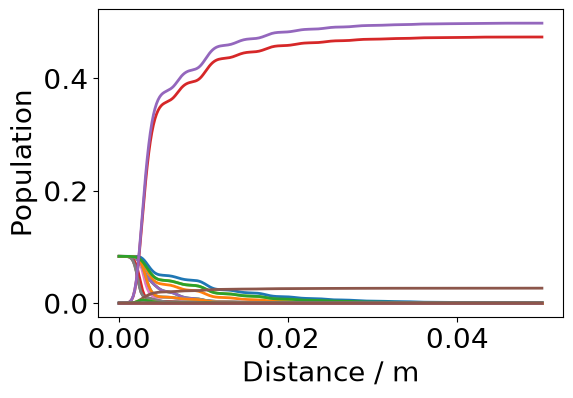

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(results.t * vz, populations, lw=2)
ax.set_xlabel("Distance / m")
ax.set_ylabel("Population")

clean_up_eff = np.sum(populations[-1, ground_idx])
nphotons = np.trapezoid(populations[:, excited_idx].sum(axis=1), x=results.t) * hamiltonian.Γ
print("state clean up efficiency =", 1 - clean_up_eff)
print("photons per molecule =", nphotons)


In [20]:
ground_final = []
for idx in ground_idx:
    state_label = obe_system.QN[idx].largest
    ax.plot(results.t * vz, populations[:, idx], lw=2, label=str(state_label))
    ground_final.append(populations[:, idx])


remainder in ground state = 0.001225337936382976
remainder in J=0 = [7.72732849e-05]
remainder in J=1, other state = 0.0
remainder in J=2 = [0.47368357]
remainder in J=3 = [0.498315]
remainder in J=4 = [0.02669882]
remainder in J=5 = []


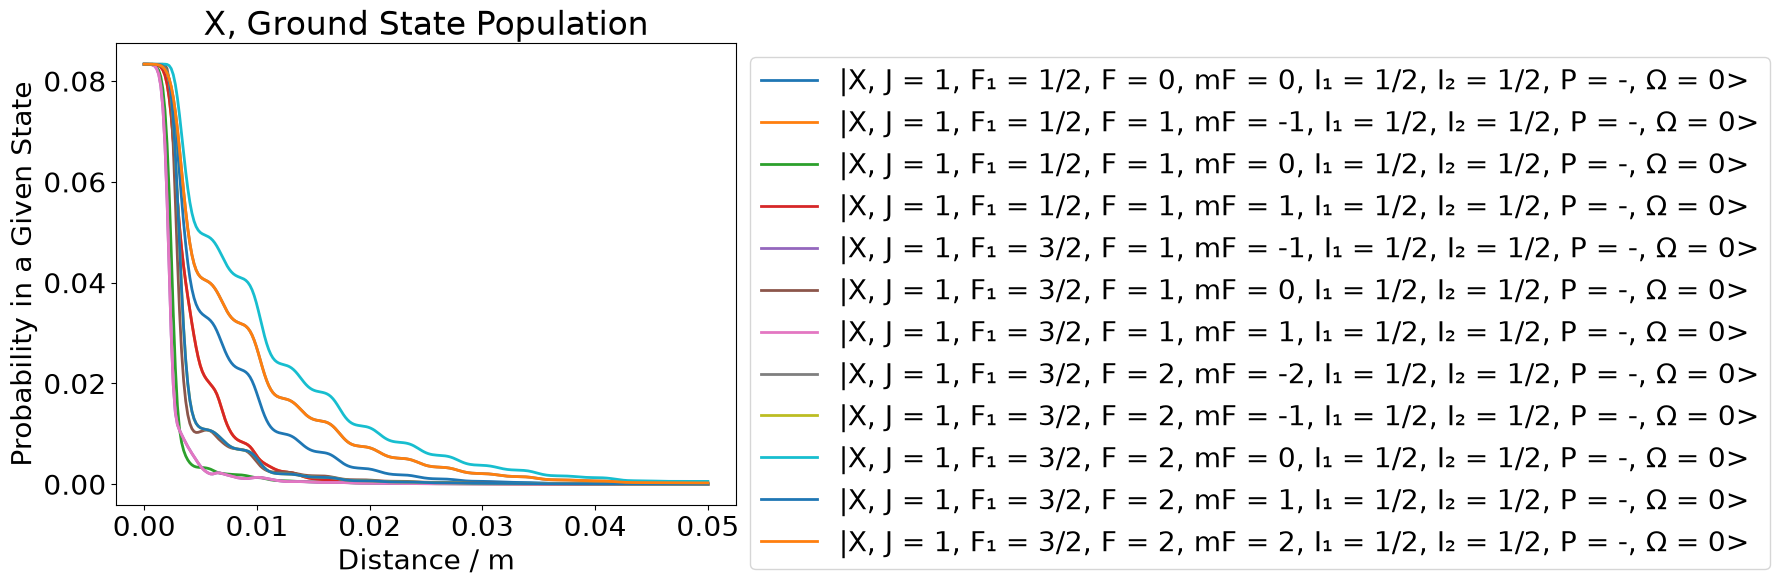

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

stop_dist = 0.05
stop = np.argmin(abs(results.t - stop_dist / vz))

ground_final = []
for idx in ground_idx:
    state_label = obe_system.QN[idx].largest
    ax.plot(results.t * vz, populations[:, idx], lw=2, label=str(state_label))
    ground_final.append(populations[-1, idx])
ax.set_title("X, Ground State Population")
ax.set_ylabel("Probability in a Given State")
ax.set_xlabel("Distance / m")
ax.legend(bbox_to_anchor=[1, 1])

print("remainder in ground state =", np.sum(ground_final))
print("remainder in J=0 =", populations[stop, J0_idx])
print("remainder in J=1, other state =", np.sum(populations[stop, J1_others_idx]))
print("remainder in J=2 =", populations[stop, J2_idx])
print("remainder in J=3 =", populations[stop, J3_idx])
print("remainder in J=4 =", populations[stop, J4_idx])
print("remainder in J=5 =", populations[stop, J5_idx])


#### Frequency scan

In [22]:
# detunings = np.linspace(-15,30,46)*2*np.pi*1e6
# phasemod = np.linspace(0,30,62)*2*np.pi*1e6
detunings = np.linspace(-15,30,6)*2*np.pi*1e6
phasemod = np.linspace(0,30,3)*2*np.pi*1e6
#moddepth = np.linspace(0,2,50)
#polmod = np.linspace(0,2,50)*2*np.pi*1e6

In [23]:
# Native Rust grid_scan replaces OBEEnsembleProblem and Julia's global `sol`.
scan_solver_options = dict(
    solver="dopri5",
    execution_mode="expanded_sparse",
    output="populations",
    output_when="final",
    dt=2e-9,
    reltol=1e-7,
    abstol=1e-9,
    maxiters=500_000,
    parallel=True,
)


In [ ]:
power_scan = np.linspace(10.e-3, 110.e-3, 5)

: 

In [ ]:
power_scan = np.linspace(10e-3, 110e-3, 5)

scan = lindblad.grid_scan(
    prepared,
    rho0,
    (0.0, t_end),
    scan={
        "laser_power": power_scan,
        "laser_detuning": detunings,
        "phase_frequency": phasemod,
    },
    **scan_solver_options,
)

# grid_scan axis order follows insertion order above: power, detuning, phase frequency.
scan_populations = scan.values.reshape(
    len(power_scan), len(detunings), len(phasemod), len(obe_system.QN)
)
result = scan_populations[..., ground_idx].sum(axis=-1).transpose(0, 2, 1)
print("result shape [power, phase frequency, detuning] =", result.shape)


In [ ]:
# save to HDF

def save_data(
    fname,
    run_name,
    scan_result,
    overwrite=True,
):
    with h5py.File(fname, "a") as f:
        if run_name in f.keys():
            if overwrite:
                del f[run_name]
        try:
            dset = f.create_dataset(run_name, data = scan_result)
        except TypeError:
            print("Error saving data!")
            return data
        
save_data(fname = "SPB_J1_cleanup.hdf", run_name = "scan_det&eom", overwrite=True, scan_result = result)

In [ ]:
def get_data(fname, run_name):
    with h5py.File(fname, "a") as f:
        dset = f[run_name]
        scan_result = np.array(dset)
    return scan_result

result = get_data(fname = "SPB_J1_cleanup.hdf", run_name = "scan_det&eom")

In [ ]:
import matplotlib
fig,ax = plt.subplots(1,3, figsize = [25,4])
cax = []
for i in [0,1,2]:
    cax.append(ax[i].pcolormesh(detunings/2/np.pi/1e6, phasemod/2/np.pi/1e6, result[2*i], shading='gouraud', norm=matplotlib.colors.LogNorm()))
    #cax.append(ax[i].pcolormesh(detunings/2/np.pi/1e6, phasemod/2/np.pi/1e6, result[2*i], shading='gouraud', vmax = 1, vmin = 0))
    ax[i].set_xlabel('Laser Detuning /MHz')
    ax[i].set_ylabel('EOM phase modulation /MHz')
    ax[i].set_title("laser power:" + str(int(power_scan[i]*1e3)) + "mW")
    cbar = fig.colorbar(cax[i])


In [ ]:
def min_max_position(values):
    return np.argmin(np.asarray(values)) + 1

# Last power slice, retained for the plotting cells below.
scan_result_ground = result[-1]


In [ ]:
import matplotlib
fig,ax = plt.subplots(figsize = [7,4])
cax = ax.pcolormesh(detunings/2/np.pi/1e6, phasemod/2/np.pi/1e6, result[4],shading='gouraud', norm=matplotlib.colors.LogNorm(vmin=result.min(), vmax=result.max()))
cbar = fig.colorbar(cax)
ax.set_xlabel('Detuning /MHz')
ax.set_ylabel('EOM phase modulation /MHz')
ax.set_title("laser power:" + str(int(power_scan[4]*1e3)) + "mW")

#### Y location & Y diamater scan

In [ ]:
yloc = np.linspace(-12, 12, 50) * 1e-3
ydia = np.linspace(10, 50, 5) * 1e-3


In [ ]:
y_scan = lindblad.grid_scan(
    prepared,
    rho0,
    (0.0, t_end),
    scan={"y0": yloc, "sigma_y": ydia / 4},
    **scan_solver_options,
)
y_populations = y_scan.values.reshape(len(yloc), len(ydia), len(obe_system.QN))
scan_result_ground = y_populations[..., ground_idx].sum(axis=-1).T
print("result shape [beam diameter, y location] =", scan_result_ground.shape)


In [ ]:
import matplotlib
fig,ax = plt.subplots(figsize = [7,4])
# cax = ax.pcolormesh(yloc * 1e3, ydia * 1e3, scan_result_ground, norm=matplotlib.colors.LogNorm())
cax = ax.pcolormesh(yloc * 1e3, ydia * 1e3, scan_result_ground, norm=matplotlib.colors.LogNorm(vmax = 0.015))
cbar = fig.colorbar(cax)
ax.set_xlabel('y location / mm')
ax.set_ylabel('y diamater/ mm')
ax.set_title("laser power:" + str(80) + "mW")

In [ ]:
save_data(fname = "SPB_J1_cleanup.hdf", run_name = "scan_yloc&ydia", overwrite=True, scan_result = scan_result_ground)